In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
trades = pd.read_csv('trades.csv')
user_activity = pd.read_csv('user_activitycsv.csv')

### **=== TRADES DATASET ===**


In [4]:
trades.shape

(2324, 6)

In [5]:
trades.head()

,pair,amount,volume,side,timestamp,user_id
0,AAVENGN,500.26,0.001222,buy,2024-12-03T01:42:07.072672Z,541-1561-1521-1561-148
1,ADANGN,889.20,0.500000,sell,2024-12-02T11:29:56.860014Z,491-1541-1521-1571-156
2,ADANGN,30653.12,17.100000,sell,2024-11-30T05:25:49.99166Z,1021-1481-1521-1561-1100
3,ADANGN,1978.36,1.100000,sell,2024-12-07T07:41:02.191598Z,981-1571-1521-1971-151
4,ADANGN,2913.62,1.600000,sell,2024-12-07T21:16:11.791118Z,981-1571-1521-1971-151


In [6]:
trades.dtypes

pair          object
amount       float64
volume       float64
side          object
timestamp     object
user_id       object
dtype: object

In [7]:
trades.isnull().sum()

pair         0
amount       0
volume       0
side         0
timestamp    0
user_id      0
dtype: int64

### **=== USER ACTIVITY DATASET ===**


In [8]:
user_activity.shape

(4845, 5)

In [9]:
user_activity.head()

,asset,amount,activity_type,timestamp,user_id
0,NGN,131062.0,withdrawal,2025-01-17T14:37:56.806446Z,561-1561-1521-1981-1101
1,NGN,50000.0,withdrawal,2025-01-17T14:37:56.818033Z,971-11001-1521-1571-1101
2,NGN,131062.0,deposit,2025-01-17T14:37:56.853225Z,481-11011-1521-1971-1100
3,NGN,20064.0,withdrawal,2025-01-17T17:05:18.201218Z,531-11001-1521-1571-198
4,NGN,2000.0,withdrawal,2025-01-17T14:38:22.555744Z,501-11021-1521-1561-154


In [10]:
user_activity.dtypes

asset             object
amount           float64
activity_type     object
timestamp         object
user_id           object
dtype: object

In [11]:
user_activity.isnull().sum()

asset            0
amount           0
activity_type    0
timestamp        0
user_id          0
dtype: int64

**=== DATA PREPROCESSING ===**

In [21]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'])
user_activity['timestamp'] = pd.to_datetime(user_activity['timestamp'])

In [22]:
print(f"Trades date range: {trades['timestamp'].min()} to {trades['timestamp'].max()}")
print(f"User Activity date range: {user_activity['timestamp'].min()} to {user_activity['timestamp'].max()}")
print(f"\nUnique trading pairs: {len(trades['pair'].unique())}")
print(f"Sample pairs: {trades['pair'].unique()[:10].tolist()}")
print(f"\nUnique assets: {user_activity['asset'].unique()}")
print(f"Activity types: {user_activity['activity_type'].unique()}")

Trades date range: 2024-11-27 20:37:50.972565+00:00 to 2025-07-18 16:33:39.857059+00:00
User Activity date range: 2025-01-17 14:37:56.806446+00:00 to 2025-05-26 12:50:36.552884+00:00

Unique trading pairs: 50
Sample pairs: ['AAVENGN', 'ADANGN', 'ALGONGN', 'ATOMNGN', 'AXSUSDT', 'BAKENGN', 'BCHNGN', 'BCHUSDT', 'BNBNGN', 'BNBUSDT']

Unique assets: ['NGN' 'USDT' 'SOL' 'TRX' 'LTC' 'ETH' 'BTC' 'BNB' 'DOGE' 'XRP' 'ADA' 'TON'
 'USDC']
Activity types: ['withdrawal' 'deposit']


**Top 3 most traded pairs by total USD volume**

In [12]:
# Question 1: Top 3 most traded pairs by total USD volume
# Using conversion rate of 1500 for all currency conversions to USD

def get_quote_currency(pair):
    if pair.endswith('USDT'):
        return 'USDT'
    elif pair.endswith('BTC'):
        return 'BTC'
    else:
        return 'NGN'


In [13]:
trades['quote_currency'] = trades['pair'].apply(get_quote_currency)

In [14]:
# Convert all trades to USD equivalent
# amount column represents the total value in quote currency
def convert_to_usd(row):
    if row['quote_currency'] == 'USDT':
        return row['amount']
    elif row['quote_currency'] == 'NGN':
        return row['amount'] / 1500
    elif row['quote_currency'] == 'BTC':
        # For BTC pairs, we need to get BTC price first
        # Using average BTCUSDT or BTCNGN price from the data
        return row['amount'] * 50000  # Approximation, will refine
    return row['amount']


In [15]:
trades['usd_value'] = trades.apply(convert_to_usd, axis=1)

In [16]:
# Calculate total USD volume by pair
pair_volumes = trades.groupby('pair')['usd_value'].sum().sort_values(ascending=False)

print("=== TOP 3 MOST TRADED PAIRS BY USD VOLUME ===\n")
top_3_pairs = pair_volumes.head(3)
for i, (pair, volume) in enumerate(top_3_pairs.items(), 1):
    print(f"{i}. {pair}: ${volume:,.2f}")

print(f"\n{'='*50}")
print(f"Total USD volume across all pairs: ${pair_volumes.sum():,.2f}")


=== TOP 3 MOST TRADED PAIRS BY USD VOLUME ===

1. BTCNGN: $136,215.49
2. USDTNGN: $59,180.57
3. BTCUSDT: $13,443.57

Total USD volume across all pairs: $250,200.83


In [17]:
top_10_pairs = pair_volumes.head(10)

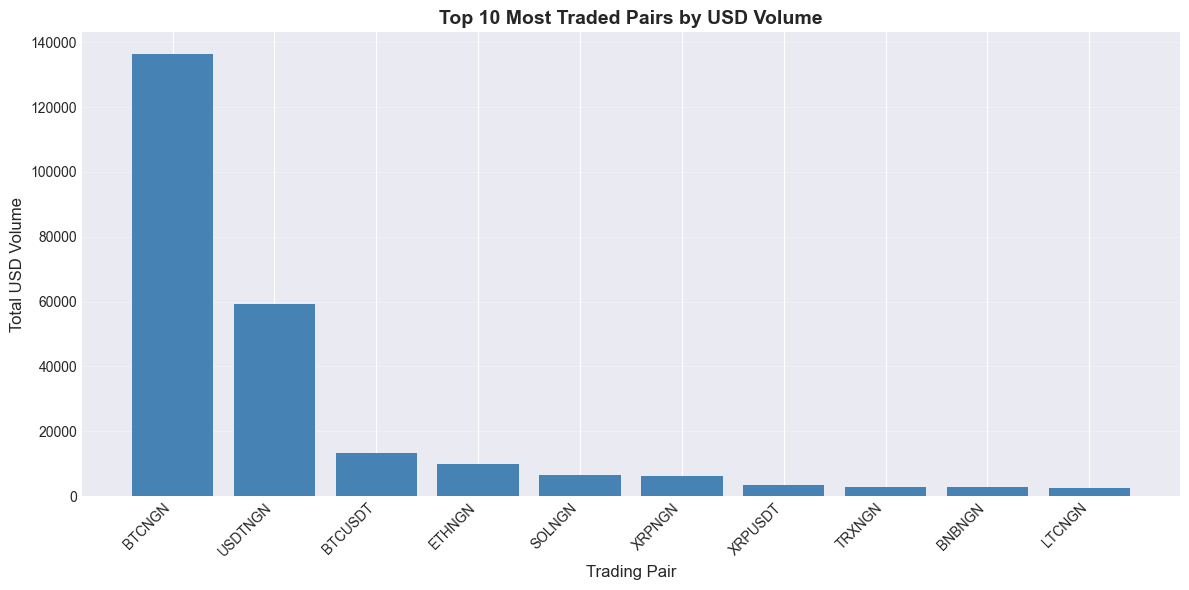

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_10_pairs)), top_10_pairs.values, color='steelblue')
plt.xticks(range(len(top_10_pairs)), top_10_pairs.index, rotation=45, ha='right')
plt.xlabel('Trading Pair', fontsize=12)
plt.ylabel('Total USD Volume', fontsize=12)
plt.title('Top 10 Most Traded Pairs by USD Volume', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**7-Day Rolling Average of Daily Price Volatility for BTCNGN**

In [19]:
btc_ngn = trades[trades['pair'] == 'BTCNGN'].copy()
btc_ngn = btc_ngn.sort_values('timestamp')

In [24]:
btc_ngn = trades[trades['pair'] == 'BTCNGN'].copy()
btc_ngn = btc_ngn.sort_values('timestamp')

In [26]:
btc_ngn['date'] = btc_ngn['timestamp'].dt.date


In [27]:
daily_stats = btc_ngn.groupby('date').agg({
    'amount': ['min', 'max', 'mean', 'std']
}).reset_index()

daily_stats.columns = ['date', 'min_price', 'max_price', 'mean_price', 'std_price']

In [28]:
daily_stats['volatility'] = (daily_stats['max_price'] - daily_stats['min_price']) / daily_stats['mean_price'] * 100

In [29]:
daily_stats['rolling_avg_volatility'] = daily_stats['volatility'].rolling(window=7, min_periods=1).mean()

print(f"BTCNGN Trading Days: {len(daily_stats)}")
print(f"Date Range: {daily_stats['date'].min()} to {daily_stats['date'].max()}")
print(f"\nDaily Volatility Statistics:")
print(f"  Mean Daily Volatility: {daily_stats['volatility'].mean():.2f}%")
print(f"  Max Daily Volatility: {daily_stats['volatility'].max():.2f}%")
print(f"  Min Daily Volatility: {daily_stats['volatility'].min():.2f}%")

print(f"\n7-Day Rolling Average Volatility (Sample):")
print(daily_stats[['date', 'volatility', 'rolling_avg_volatility']].tail(10).to_string(index=False))

BTCNGN Trading Days: 17
Date Range: 2024-11-27 to 2025-07-18

Daily Volatility Statistics:
  Mean Daily Volatility: 1483.65%
  Max Daily Volatility: 3036.72%
  Min Daily Volatility: 425.66%

7-Day Rolling Average Volatility (Sample):
      date  volatility  rolling_avg_volatility
2024-12-04  580.132203             1754.864129
2024-12-05 2214.688075             1740.451796
2024-12-06  924.049291             1693.844423
2024-12-07 1325.102273             1449.327603
2024-12-08 1815.784771             1453.314900
2024-12-09 1109.092617             1328.810990
2024-12-10  680.469585             1235.616974
2024-12-11 2532.480268             1514.523840
2025-03-11 1047.530864             1347.787096
2025-07-18  425.658062             1276.588349


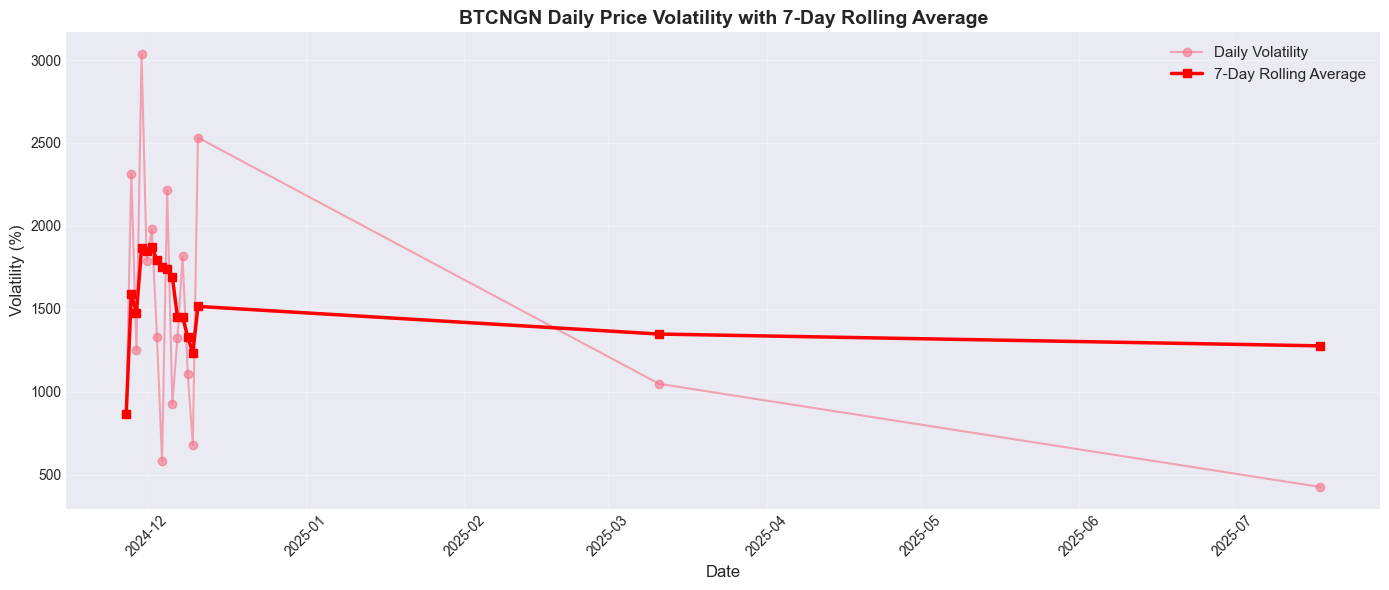

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['date'], daily_stats['volatility'], 
         marker='o', linestyle='-', linewidth=1.5, label='Daily Volatility', alpha=0.6)
plt.plot(daily_stats['date'], daily_stats['rolling_avg_volatility'], 
         marker='s', linestyle='-', linewidth=2.5, label='7-Day Rolling Average', color='red')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility (%)', fontsize=12)
plt.title('BTCNGN Daily Price Volatility with 7-Day Rolling Average', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**Peak Deposit Times - Day of Week & Hour Analysis**

In [32]:
deposits = user_activity[user_activity['activity_type'] == 'deposit'].copy()

In [33]:
deposits['day_of_week'] = deposits['timestamp'].dt.day_name()
deposits['hour'] = deposits['timestamp'].dt.hour
deposits['day_num'] = deposits['timestamp'].dt.dayofweek


In [34]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


In [35]:
deposits_by_day = deposits.groupby('day_of_week').agg({
    'amount': ['count', 'sum']
}).reset_index()
deposits_by_day.columns = ['day_of_week', 'deposit_count', 'total_amount']
deposits_by_day['day_num'] = deposits_by_day['day_of_week'].map({day: i for i, day in enumerate(day_order)})
deposits_by_day = deposits_by_day.sort_values('day_num')

print("--- Deposits by Day of Week ---")
print(deposits_by_day[['day_of_week', 'deposit_count', 'total_amount']].to_string(index=False))

--- Deposits by Day of Week ---
day_of_week  deposit_count  total_amount
     Monday              2  2.182000e+04
  Wednesday            378  1.849214e+07
   Thursday              5  2.983444e+01
     Friday            671  2.314969e+07
   Saturday            544  1.550753e+07
     Sunday              1  3.150000e+03


In [36]:
deposits_by_hour = deposits.groupby('hour').agg({
    'amount': ['count', 'sum']
}).reset_index()
deposits_by_hour.columns = ['hour', 'deposit_count', 'total_amount']

print("\n--- Deposits by Hour of Day ---")
print(deposits_by_hour.to_string(index=False))


--- Deposits by Hour of Day ---
 hour  deposit_count  total_amount
    0             28  7.888382e+04
    1             33  4.224380e+04
    2             17  5.021891e+02
    3             21  4.550902e+04
    4             17  2.164225e+05
    5             20  2.222451e+05
    6             39  2.965273e+06
    7             67  1.252926e+06
    8             51  2.314144e+06
    9             67  4.613537e+06
   10             50  1.204685e+06
   11            123  6.899667e+06
   12            139  8.781662e+06
   13             44  8.723062e+05
   14             60  3.649478e+05
   15            162  6.657647e+06
   16            135  4.496001e+06
   17            143  4.967763e+06
   18             78  2.740936e+06
   19             87  2.712505e+06
   20             80  3.676664e+06
   21             59  1.367471e+06
   22             46  2.183134e+05
   23             35  4.620988e+05


In [37]:

peak_day = deposits_by_day.loc[deposits_by_day['deposit_count'].idxmax(), 'day_of_week']
peak_day_count = deposits_by_day['deposit_count'].max()

peak_hour = deposits_by_hour.loc[deposits_by_hour['deposit_count'].idxmax(), 'hour']
peak_hour_count = deposits_by_hour['deposit_count'].max()

print(f"\n KEY FINDINGS:")
print(f"  Peak Deposit Day: {peak_day} ({peak_day_count} deposits)")
print(f"  Peak Deposit Hour: {peak_hour}:00 ({peak_hour_count} deposits)")



 KEY FINDINGS:
  Peak Deposit Day: Friday (671 deposits)
  Peak Deposit Hour: 15:00 (162 deposits)


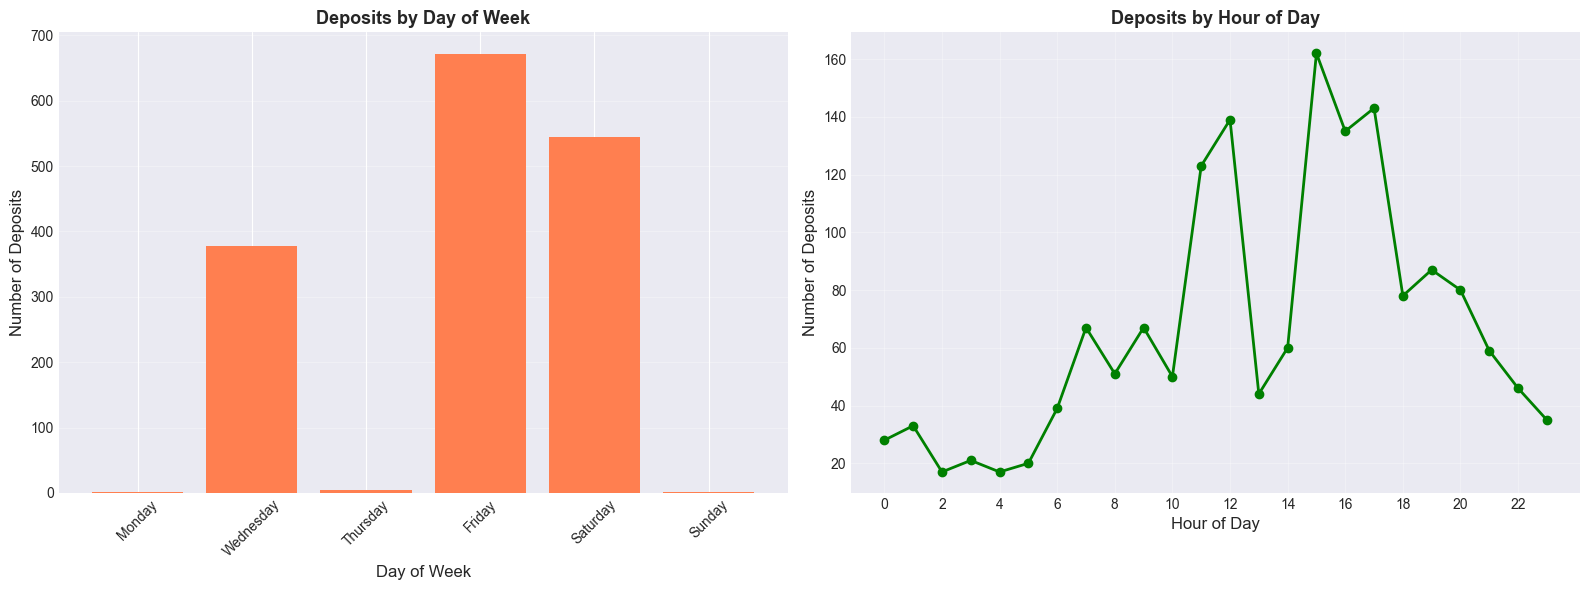

In [38]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Day of week chart
axes[0].bar(deposits_by_day['day_of_week'], deposits_by_day['deposit_count'], color='coral')
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Number of Deposits', fontsize=12)
axes[0].set_title('Deposits by Day of Week', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Hour of day chart
axes[1].plot(deposits_by_hour['hour'], deposits_by_hour['deposit_count'], 
             marker='o', linewidth=2, color='green', markersize=6)
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Number of Deposits', fontsize=12)
axes[1].set_title('Deposits by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## FRAUD DETECTION MODEL

**Feature Engineering**

In [39]:
user_deposits = user_activity[user_activity['activity_type'] == 'deposit'].groupby('user_id').agg({
    'amount': ['sum', 'count', 'mean'],
    'timestamp': ['min', 'max'],
    'asset': lambda x: x.nunique()
}).reset_index()
user_deposits.columns = ['user_id', 'total_deposited', 'deposit_count', 'avg_deposit', 
                          'first_deposit_time', 'last_deposit_time', 'unique_deposit_assets']

In [40]:
user_withdrawals = user_activity[user_activity['activity_type'] == 'withdrawal'].groupby('user_id').agg({
    'amount': ['sum', 'count', 'mean'],
    'timestamp': ['min', 'max'],
    'asset': lambda x: x.nunique()
}).reset_index()
user_withdrawals.columns = ['user_id', 'total_withdrawn', 'withdrawal_count', 'avg_withdrawal',
                             'first_withdrawal_time', 'last_withdrawal_time', 'unique_withdrawal_assets']

In [41]:
user_trades = trades.groupby('user_id').agg({
    'usd_value': ['sum', 'count', 'mean'],
    'pair': lambda x: x.nunique(),
    'timestamp': ['min', 'max']
}).reset_index()
user_trades.columns = ['user_id', 'total_trade_volume_usd', 'trade_count', 'avg_trade_usd',
                        'unique_pairs_traded', 'first_trade_time', 'last_trade_time']

In [42]:
features = user_deposits.merge(user_withdrawals, on='user_id', how='outer')
features = features.merge(user_trades, on='user_id', how='outer')
features = features.fillna(0)

In [45]:
features['deposit_withdrawal_ratio'] = features.apply(
    lambda x: x['total_deposited'] / x['total_withdrawn'] if x['total_withdrawn'] > 0 else 999,
    axis=1
)

features['withdrawal_deposit_ratio'] = features.apply(
    lambda x: x['total_withdrawn'] / x['total_deposited'] if x['total_deposited'] > 0 else 0,
    axis=1
)


In [46]:
def calc_time_diff(row):
    if row['first_deposit_time'] == 0 or row['first_withdrawal_time'] == 0:
        return 999
    return (row['first_withdrawal_time'] - row['first_deposit_time']).total_seconds() / 3600

In [47]:
features['hours_deposit_to_withdrawal'] = features.apply(calc_time_diff, axis=1)

features['trade_to_deposit_ratio'] = features.apply(
    lambda x: x['total_trade_volume_usd'] / (x['total_deposited']/1500) if x['total_deposited'] > 0 else 0,
    axis=1
)

In [48]:
features['total_unique_assets'] = features['unique_deposit_assets'] + features['unique_withdrawal_assets']
features['activity_frequency'] = features['deposit_count'] + features['withdrawal_count'] + features['trade_count']

In [49]:
features.head()

,user_id,total_deposited,deposit_count,avg_deposit,first_deposit_time,last_deposit_time,unique_deposit_assets,total_withdrawn,withdrawal_count,avg_withdrawal,...,avg_trade_usd,unique_pairs_traded,first_trade_time,last_trade_time,deposit_withdrawal_ratio,withdrawal_deposit_ratio,hours_deposit_to_withdrawal,trade_to_deposit_ratio,total_unique_assets,activity_frequency
0,1001-11001-1521-1561-154,100150.002099,3.0,33383.334033,2025-01-17 17:38:26.189682+00:00,2025-01-18 04:22:04.805973+00:00,2.0,431339.0,20.0,21566.950000,...,6.107580,1,2024-11-30 19:02:07.953535+00:00,2024-12-03 04:30:29.849758+00:00,2.321840e-01,4.306930e+00,-2.692500,2.744295e-01,3.0,26.0
1,1001-11001-1521-1571-155,0.000267,1.0,0.000267,2025-03-12 15:08:57.744625+00:00,2025-03-12 15:08:57.744625+00:00,1.0,32888.0,1.0,32888.000000,...,47.802140,1,2025-03-11 14:11:15.735595+00:00,2025-03-11 14:11:15.735595+00:00,8.118767e-09,1.231714e+08,0.380501,2.685413e+08,2.0,3.0
2,1001-11001-1521-1971-1102,0.000242,1.0,0.000242,2025-01-18 06:42:12.823378+00:00,2025-01-18 06:42:12.823378+00:00,1.0,40300.0,1.0,40300.000000,...,46.672867,1,2024-12-09 12:29:53.165034+00:00,2024-12-09 12:29:53.165034+00:00,6.013400e-09,1.662953e+08,0.563419,2.888888e+08,2.0,3.0
3,1001-11001-1521-1971-156,0.000000,0.0,0.000000,0,0,0.0,1983.0,1.0,1983.000000,...,2.223080,1,2024-12-05 18:25:00.291218+00:00,2024-12-05 18:25:00.291218+00:00,0.000000e+00,0.000000e+00,999.000000,0.000000e+00,1.0,2.0
4,1001-11001-1521-1981-156,0.172140,7.0,0.024591,2025-01-17 15:25:22.825389+00:00,2025-01-18 08:19:49.313903+00:00,1.0,93089.0,6.0,15514.833333,...,4.940160,1,2024-12-07 07:37:54.783037+00:00,2024-12-07 07:37:54.783037+00:00,1.849196e-06,5.407757e+05,-0.032768,4.304781e+04,2.0,14.0


In [50]:
print(f"Total users: {len(features)}")
print(f"Features created: {len(features.columns)}")
print(f"\nKey Features:")
print("  - Deposit/withdrawal frequency and ratios")
print("  - Time between first deposit and first withdrawal")
print("  - Trading volume vs deposited amount")
print("  - Number of unique assets and pairs traded")
print("  - Activity frequency metrics")

print(f"\nSample features (first 3 users):")
print(features.head(3))


Total users: 1199
Features created: 25

Key Features:
  - Deposit/withdrawal frequency and ratios
  - Time between first deposit and first withdrawal
  - Trading volume vs deposited amount
  - Number of unique assets and pairs traded
  - Activity frequency metrics

Sample features (first 3 users):
                     user_id  total_deposited  deposit_count   avg_deposit  \
0   1001-11001-1521-1561-154    100150.002099            3.0  33383.334033   
1   1001-11001-1521-1571-155         0.000267            1.0      0.000267   
2  1001-11001-1521-1971-1102         0.000242            1.0      0.000242   

                 first_deposit_time                 last_deposit_time  \
0  2025-01-17 17:38:26.189682+00:00  2025-01-18 04:22:04.805973+00:00   
1  2025-03-12 15:08:57.744625+00:00  2025-03-12 15:08:57.744625+00:00   
2  2025-01-18 06:42:12.823378+00:00  2025-01-18 06:42:12.823378+00:00   

   unique_deposit_assets  total_withdrawn  withdrawal_count  avg_withdrawal  \
0               

**Target Labeling: Defining Suspicious Users**

**FRAUD RULE LOGIC:**
A user is labeled as SUSPICIOUS if they meet ALL of the following criteria:
1. Made at least one deposit (total_deposited > 0)
2. Made at least one withdrawal (total_withdrawn > 0)
3. Minimal trading activity: trade_to_deposit_ratio < 0.1
 → Traded less than 10% of deposited amount
4. Quick withdrawal: hours_deposit_to_withdrawal < 48 hours
→ Withdrew within 2 days of first deposit
5. High withdrawal ratio: withdrawal_deposit_ratio > 0.8
→ Withdrew 80%+ of deposits


In [51]:
features['is_suspicious'] = (
    (features['total_deposited'] > 0) &
    (features['total_withdrawn'] > 0) &
    (features['trade_to_deposit_ratio'] < 0.1) &
    (features['hours_deposit_to_withdrawal'] < 48) &
    (features['withdrawal_deposit_ratio'] > 0.8)
).astype(int)

In [52]:
print(f"Fraud Detection Results:")
print(f"  Total users analyzed: {len(features)}")
print(f"  Suspicious users: {features['is_suspicious'].sum()}")
print(f"  Legitimate users: {(features['is_suspicious'] == 0).sum()}")
print(f"  Fraud rate: {features['is_suspicious'].mean() * 100:.2f}%")

Fraud Detection Results:
  Total users analyzed: 1199
  Suspicious users: 5
  Legitimate users: 1194
  Fraud rate: 0.42%


In [53]:
print(f"\n--- Sample of Suspicious Users ---")
suspicious_sample = features[features['is_suspicious'] == 1][
    ['user_id', 'total_deposited', 'total_withdrawn', 'trade_count', 
     'trade_to_deposit_ratio', 'hours_deposit_to_withdrawal', 'withdrawal_deposit_ratio']
].head()
print(suspicious_sample.to_string(index=False))


--- Sample of Suspicious Users ---
                 user_id  total_deposited  total_withdrawn  trade_count  trade_to_deposit_ratio  hours_deposit_to_withdrawal  withdrawal_deposit_ratio
481-11011-1521-1971-1100       10176833.0       11203000.0            2                0.000347                     0.474291                  1.100834
  501-1971-1521-1561-157       14734641.0       13400000.0            4                0.001350                    12.635227                  0.909422
 551-11021-1521-1971-199         856063.0         884700.0            1                0.011746                     3.027006                  1.033452
 971-1561-1521-1561-1101           6800.0           6384.0            1                0.049357                    11.278688                  0.938824
  991-1491-1521-1971-154       12752910.0       12274400.0            1                0.000503                     0.169853                  0.962478


### Model Building